# <font color='brown'> **The Application of Machine Learning Methods for Predicting Customer Satisfaction and Purchase Intention in Supermarket X** </font>

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

## <font color='indianred'> **Preliminary Data Analysis**</font>

In [2]:
data = pd.read_excel('dane_projekt2024.xlsx')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7769 entries, 0 to 7768
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   asortyment  7769 non-null   int64  
 1   obsluga     7769 non-null   int64  
 2   dni         7769 non-null   int64  
 3   dochod      7769 non-null   float64
 4   inne        7769 non-null   int64  
 5   internet    7769 non-null   int64  
 6   kredytowa   7769 non-null   int64  
 7   wiek        7769 non-null   int64  
 8   plec        7769 non-null   int64  
 9   pozyczka    7769 non-null   int64  
 10  odleglosc   7769 non-null   float64
 11  zakupy      7769 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 728.5 KB


In [3]:
data.drop(data.index[2800:3100],inplace=True)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7469 entries, 0 to 7768
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   asortyment  7469 non-null   int64  
 1   obsluga     7469 non-null   int64  
 2   dni         7469 non-null   int64  
 3   dochod      7469 non-null   float64
 4   inne        7469 non-null   int64  
 5   internet    7469 non-null   int64  
 6   kredytowa   7469 non-null   int64  
 7   wiek        7469 non-null   int64  
 8   plec        7469 non-null   int64  
 9   pozyczka    7469 non-null   int64  
 10  odleglosc   7469 non-null   float64
 11  zakupy      7469 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 758.6 KB


As can be seen, the final dataset consists of 7,469 observations, with no missing values for any of the variables.

In [5]:
data.head()

,asortyment,obsluga,dni,dochod,inne,internet,kredytowa,wiek,plec,pozyczka,odleglosc,zakupy
0,54,64,2,2.1,3,0,0,54,0,1,1.6,1
1,86,88,6,2.3,2,0,1,72,1,1,6.5,1
2,56,60,2,2.1,3,0,0,56,1,0,0.4,1
3,54,61,2,2.1,3,0,1,60,1,1,6.5,1
4,63,60,2,2.1,3,0,0,41,1,1,7.3,1


asortyment - product range <br>
obsluga - customer service<br>
dni - days<br>
dochod - income<br>
inne - other<br>
internet - internet<br>
kredytowa - credit card<br>
wiek - age<br>
plec - gender<br>
pozyczka - loan<br>
odleglosc - distance<br>
zakupy - purchase intention<br>

### **Descriptive Statistics**

In [6]:
metric = data[['asortyment', 'obsluga', 'dni', 'dochod', 'inne', 'wiek', 'odleglosc']]
metric.describe().round(2)

,asortyment,obsluga,dni,dochod,inne,wiek,odleglosc
count,7469.00,7469.00,7469.00,7469.00,7469.00,7469.00,7469.00
mean,41.74,53.12,3.99,2.39,3.24,47.88,11.84
std,26.45,31.51,1.50,0.66,1.53,12.90,7.67
min,0.00,0.00,2.00,1.00,1.00,18.00,0.10
25%,19.00,26.00,3.00,2.00,2.00,38.00,5.60
50%,40.00,56.00,4.00,2.30,4.00,48.00,11.00
75%,60.00,81.00,5.00,2.80,5.00,57.00,17.30
max,90.00,100.00,7.00,3.90,6.00,74.00,102.00


The descriptive statistics for the metric variables are presented above.

The average satisfaction with the product range is 41.74 points. The values deviate from the mean by an average of 26.45 points, which corresponds to a coefficient of variation of approximately 63%. The minimum value recorded in the survey is 0 points, while the maximum is 90 points. The mean is higher than the median, indicating a right-skewed distribution and, consequently, a predominance of relatively low ratings.<br> 
The average satisfaction with customer service is 53.12 points, which is higher than the average satisfaction with the product range. The standard deviation is 31.5, corresponding to a coefficient of variation of approximately 59%. The minimum rating is also 0 points, while the maximum rating for customer service is 100 points. Based on these values, customer service can be considered to be rated more highly on average than the product range offered by the supermarket. The mean is lower than the median, indicating a predominance of relatively high ratings. <br>

On average, a customer shops on 4 days per week. The standard deviation for this variable is 1.5, indicating relatively low dispersion (38%). The minimum number of days on which a customer shops is 2, while the maximum is 7, meaning that some customers shop every day. The mean is slightly lower than the median, indicating a slight predominance of observations with relatively high values.<br>

The average customer income is 2.39 units. The standard deviation is 0.66, indicating relatively low variability (28%). The minimum recorded customer income is 1 unit, while the maximum is 3.9 units. The mean is higher than the median, indicating a predominance of customers with relatively low income values.<br>

On average, a customer shops at 3 other supermarkets. The minimum recorded value is 1, while the maximum number of other supermarkets visited is 6. The mean is lower than the median, indicating a greater number of customers who shop at a relatively high number of other supermarkets.<br>

The average customer age is 47.88 years. The standard deviation is 12.9 years, corresponding to a coefficient of variation of approximately 27%. The mean is slightly lower than the median.<br>

The average distance between a customer’s place of residence and the supermarket is 11.84 km. The values deviate from the mean by an average of 7.67 km. The minimum distance is 100 metres, while the maximum is 102 km. The mean is higher than the median, indicating a predominance of customers living at relatively shorter distances from the supermarket.<br>

In [7]:
summary = pd.DataFrame({
    column: (data[column].value_counts(normalize=True)*100).round(2)
    for column in ['internet', 'kredytowa','plec','pozyczka','zakupy']
})

In [8]:
summary

,internet,kredytowa,plec,pozyczka,zakupy
0,51.09,63.69,54.91,11.74,52.35
1,48.91,36.31,45.09,88.26,47.65


Above table is also presented with plot below.

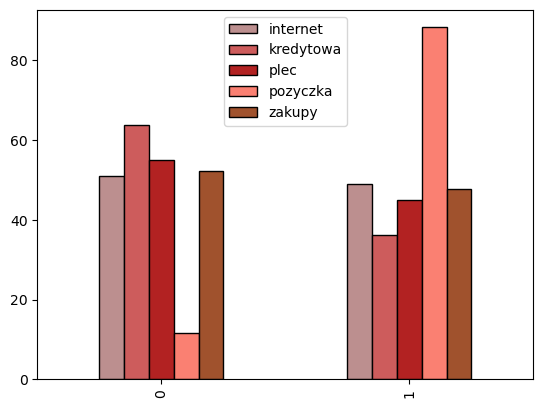

In [9]:
summary.plot.bar(color =['rosybrown', 'indianred', 'firebrick','salmon', 'sienna'], edgecolor = 'black')
plt.legend(loc = 'upper center')

More than 51% of the surveyed customers do not shop online, while 63.69% of respondents do not own a credit card. The gender distribution is relatively balanced, with 55% of respondents being male and 45% female. As many as 88% of customers have some form of financial liability, such as a loan, credit agreement, or payday loan. Furthermore, 52% of respondents do not intend to shop at the surveyed supermarket in the future.

### **Visualization of Selected Variables**

Initially, the presence of outliers among the metric variables was examined using box plots. The variables were divided into two groups due to differences in their orders of magnitude.

<Axes: >

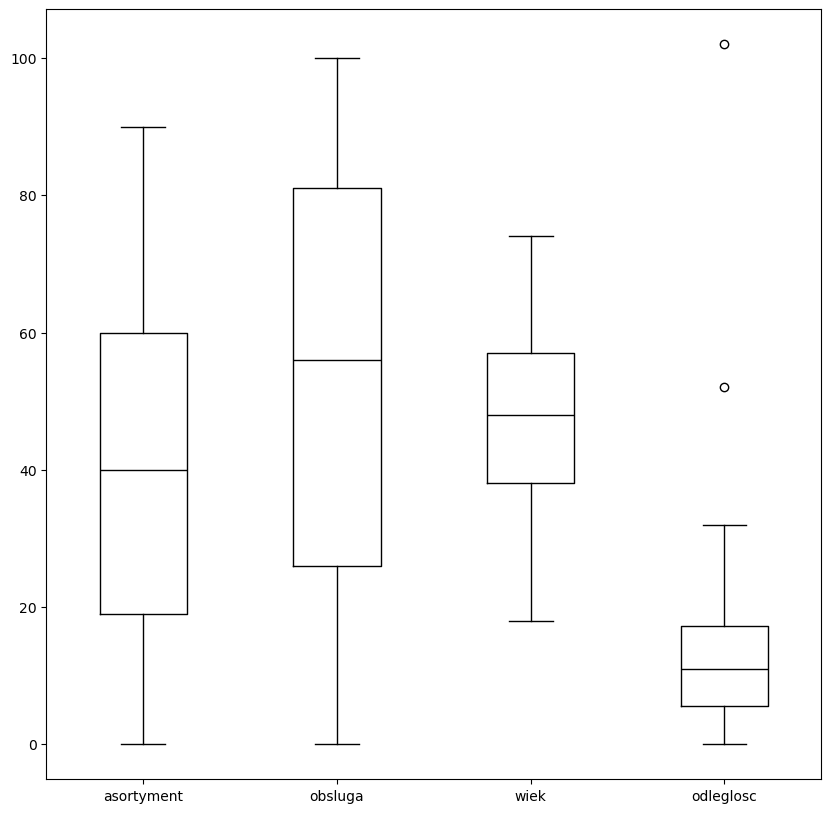

In [10]:
metric[['asortyment','obsluga','wiek','odleglosc']].plot.box(figsize = (10,10),
                         color = 'black')

<Axes: >

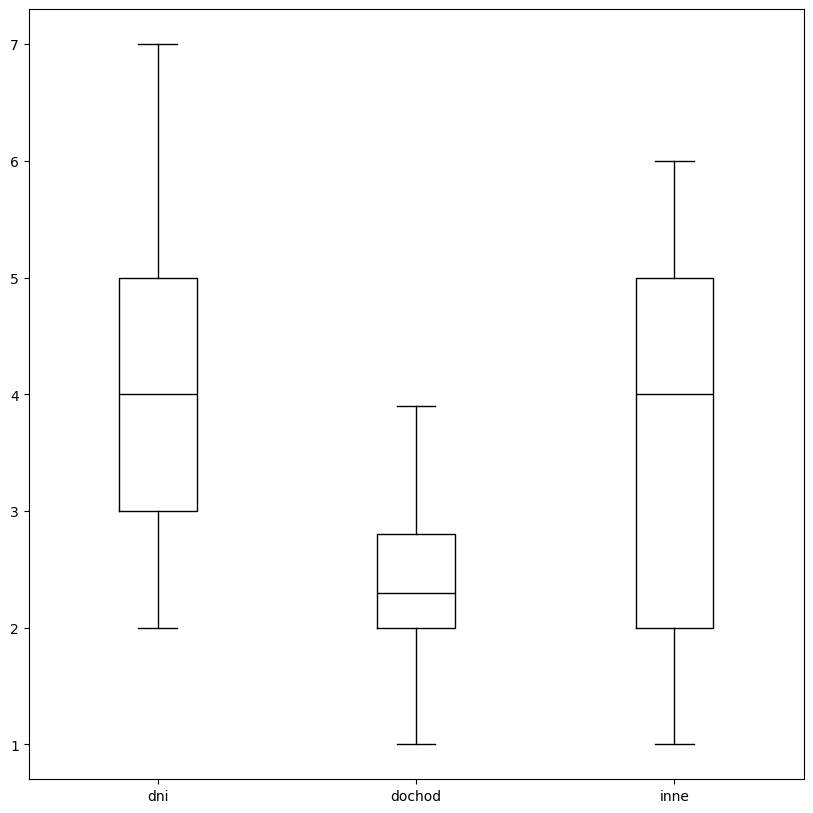

In [11]:
metric[['dni','dochod','inne']].plot.box(figsize = (10,10),
                         color = 'black')

As shown in the figures above, outliers are present only for the Distance. However, since they account for less than 5% of the observations, it was decided to retain them in the dataset.

Next, scatter plots were created for the metric variables, excluding the Days and Other due to their discrete nature and limited range of values (from 1 to 7).

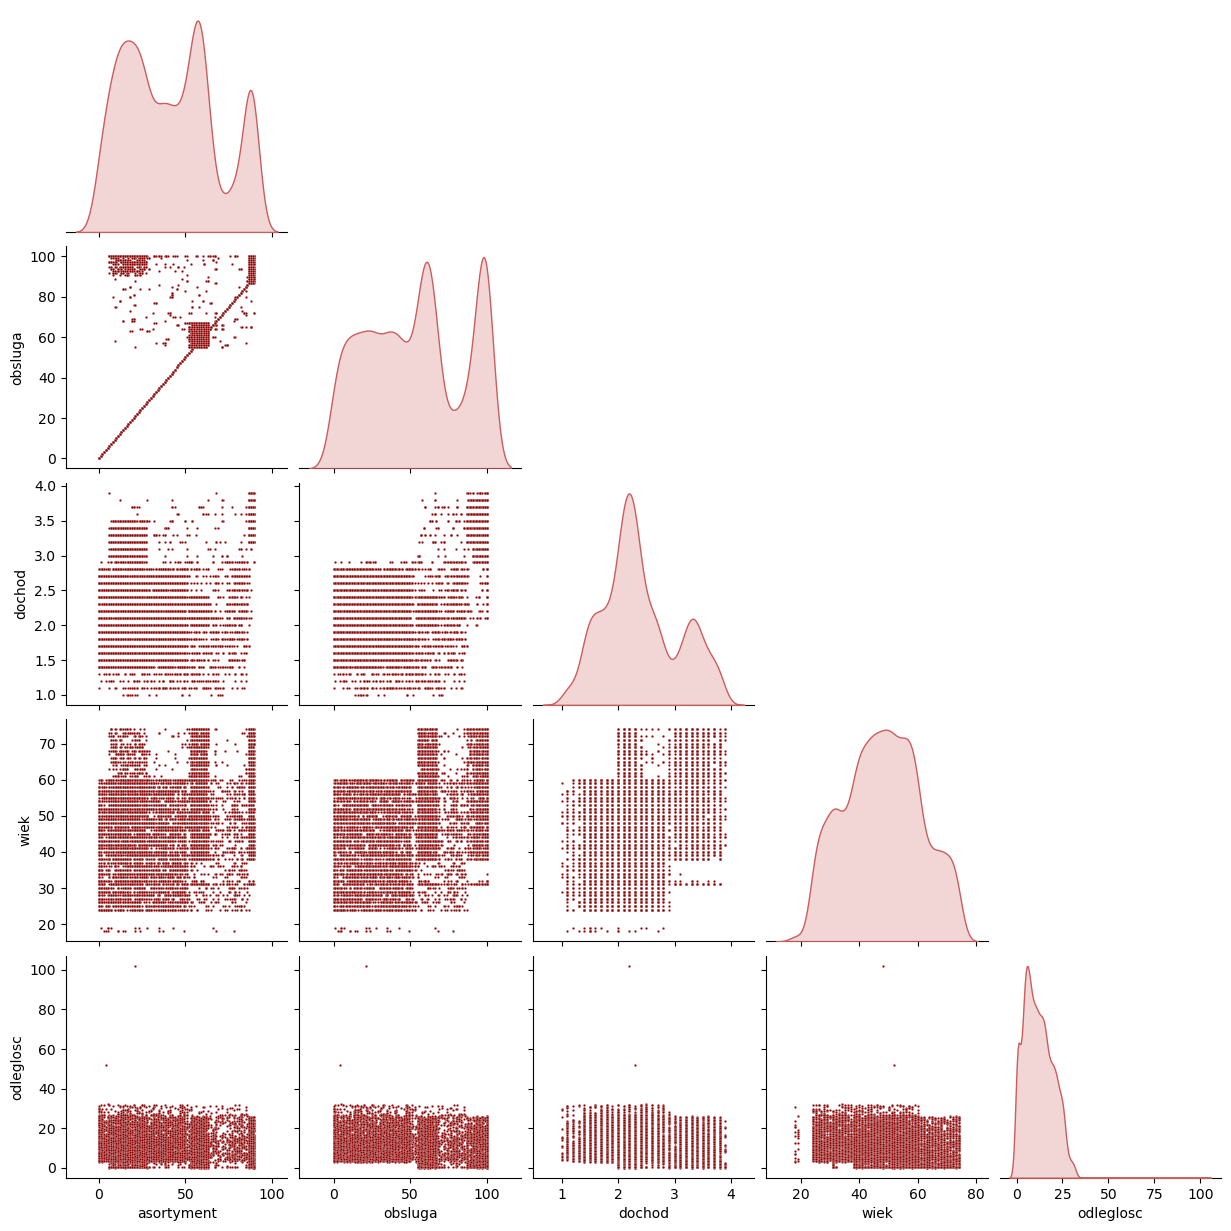

In [12]:
sns.pairplot(metric[['asortyment','obsluga','dochod','wiek','odleglosc']], 
             plot_kws ={'color': 'darkred', 's':3}, 
             diag_kws = {'color': 'indianred'},
             diag_kind = 'kde',
            corner = True)
plt.show()

It should be noted that no clear linear correlation is observed for most pairs of variables. The only exception is the relationship between satisfaction with customer service and satisfaction with the product range, for which a linear relationship appears to be present. However, for observations where customer service satisfaction exceeds 60 points, this relationship seems to weaken. <br>

The age variable exhibits a distribution closest to the normal distribution. The remaining variables are characterized by asymmetric, bimodal, or trimodal distributions.

Next, the relationship between customer service satisfaction and product range satisfaction was examined using a scatter plot, with observations distinguished according to whether customers intended to shop at the supermarket in the future.

<Axes: xlabel='asortyment', ylabel='obsluga'>

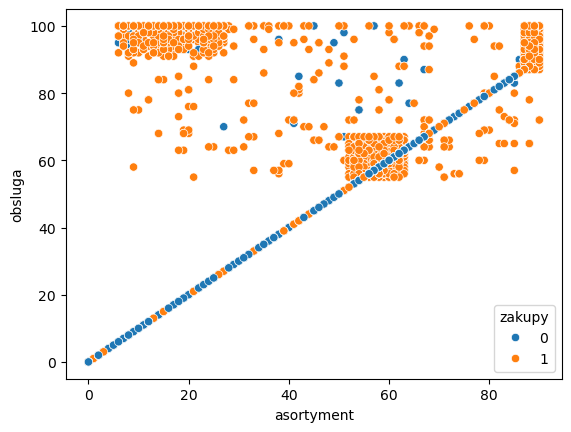

In [13]:
sns.scatterplot(data=data, x='asortyment', y='obsluga', hue='zakupy')

It can be observed that among customers whose satisfaction with customer service exceeds 55 points, the majority intend to shop at the supermarket in the future. Moreover, the observations corresponding to customers who do not intend to return to the supermarket appear to follow a relatively linear pattern, whereas a greater degree of dispersion is observed among customers who intend to return. <br>

This may suggest that customers who do not plan to shop at Supermarket X in the future tend to evaluate the product range and customer service similarly. In contrast, among customers who intend to return, satisfaction with one of these aspects may be considerably higher than satisfaction with the other. It should also be noted that the weakening of the linear relationship observed in the previous plot appears to be primarily associated with the group of customers who intend to shop at the supermarket again in the future.

## <font color='indianred'> **Methods** </font>

### **Logistic regression**

Logistic regression is a statistical method commonly used for binary classification problems. It estimates the probability that an observation belongs to one of two possible classes. The model uses a linear combination of the explanatory variables as its input and applies the logistic function to transform the resulting value into a probability between 0 and 1. <br>

In logistic regression, the classification threshold is the cut-off value used to assign an observation to one of the two classes. If the predicted probability exceeds the selected threshold, the observation is assigned to one class; otherwise, it is assigned to the other. The threshold therefore represents a key decision boundary that converts predicted probabilities into class predictions. The default threshold is typically set at 0.5. However, the choice of an appropriate classification threshold should be adjusted to the characteristics and objectives of the specific classification problem.

### **Decision tree**

Decision trees can be divided into classification and regression trees. A classification tree is an algorithm built recursively by selecting the feature that best splits the data into subsets. Internal nodes represent features, branches represent decision rules, and leaf nodes represent the predicted classes.<br>

The process of building a decision tree begins at the root node. At each step, the best feature and split point are selected according to a specified criterion, such as entropy or the Gini index. Lower values of entropy or the Gini index indicate lower node impurity. The splitting process continues until a stopping criterion is met, for example, when the maximum tree depth is reached, the number of observations in a node is too small, all observations belong to the same class, or no further meaningful improvement in the splitting criterion can be achieved.<br>

In regression trees, the objective is to predict a continuous target variable. The data are commonly split by minimizing a measure of prediction error, such as the mean squared error (MSE).<br>

To reduce the risk of overfitting, the complexity of a decision tree can be controlled through pruning. This can be performed using **pre-pruning**, where the growth of the tree is restricted during the training process, or **post-pruning**, where selected branches are removed after the tree has been constructed.

### **Random forest**

A random forest is an ensemble of decision trees. Randomness is introduced in two main ways: by randomly selecting observations used to construct individual trees and by randomly selecting subsets of features considered when searching for the best split<br>

Observations used to train individual trees are typically selected using bootstrap sampling, i.e., random sampling with replacement. In addition, only a randomly selected subset of features is considered at each split. The number of features considered depends on the model configuration and implementation. A commonly used default for classification problems is the square root of the total number of features. <br>

For regression problems, the final prediction of a quantitative target variable is typically obtained by averaging the predictions produced by all trees in the forest. In classification problems, predictions can be obtained by aggregating the predictions of individual trees, for example by averaging the predicted class probabilities and assigning the observation to the class with the highest resulting probability.

### **Extra trees**

Extra Trees (Extremely Randomized Trees) is an ensemble learning algorithm closely related to Random Forest. Similarly to Random Forest, it constructs multiple decision trees and considers random subsets of features when determining node splits.<br>

The main difference lies in the additional source of randomness introduced during tree construction. While Random Forest searches for the optimal split threshold among the candidate features, Extra Trees randomly generates split thresholds for each candidate feature. The best split among these randomly generated candidates is then selected according to the chosen splitting criterion.<br>

This additional randomization may reduce the variance of the model and, consequently, its tendency to overfit. It can also make the training process faster than in Random Forest, as the algorithm does not need to search extensively for the optimal split threshold for each candidate feature.

### **KNN**

The K-Nearest Neighbors (KNN) algorithm is based on identifying the *k* observations that are closest to a given observation. The number of neighbors, *k*, is a hyperparameter, and there is no universally optimal value. Therefore, models with different values of *k* are typically evaluated using a validation procedure in order to select an appropriate value.<br>

The nearest neighbors are identified based on the distance between observations. In this study, only quantitative variables were used in the KNN model, and the distance between observations was calculated using Euclidean distance. Since distance-based algorithms are sensitive to differences in the scales of variables, the variables should be scaled before fitting the model. <br>

After scaling, the distances between observations are calculated and the *k* nearest neighbors are identified. In a regression problem, the predicted value is typically obtained by averaging the values of the target variable among the selected neighbors. In a classification problem, the predicted class is usually determined based on the classes of the nearest neighbors, for example through majority voting.

## <font color='indianred'> **Regression problem** </font>

The following variables were selected to predict customer satisfaction with service: <br>

- **Product range** – satisfaction with the product range may also indirectly influence customers’ overall perception of service quality in the supermarket.<br>
- **Gender** – perceptions of service quality may differ depending on gender.<br>
- **Age** – perceptions and expectations regarding service quality may vary across age groups.<br>
- **Income** – customers with higher incomes may have different expectations regarding customer service compared with customers with lower incomes.<br>
- **Days** – customers who shop more frequently may be more familiar with and accustomed to the service standards offered by the supermarket.<br>
- **Other supermarkets** – customers who shop at a larger number of other supermarkets have a broader basis for comparing service quality.<br>
- **Distance** – customers who travel longer distances to reach the supermarket may particularly value its overall quality, including the quality of customer service.<br>
- **Purchase intention** – a customer’s intention to shop at the supermarket in the future may be associated with their satisfaction with the service<br>
- **Online shopping** – customers who shop online may have different expectations regarding the speed and quality of service compared with customers who prefer traditional in-store shopping.<br>

For the KNN algorithm, the **gender**, **purchase intention**, and **online shopping** variables were excluded from the set of predictors, as only quantitative variables were included in this model.

### **KNN**

In [14]:
X = data[['wiek','dochod','dni','inne','odleglosc','asortyment']]
X.head()

,wiek,dochod,dni,inne,odleglosc,asortyment
0,54,2.1,2,3,1.6,54
1,72,2.3,6,2,6.5,86
2,56,2.1,2,3,0.4,56
3,60,2.1,2,3,6.5,54
4,41,2.1,2,3,7.3,63


In [15]:
y = data['obsluga']
y.head()

0    64
1    88
2    60
3    61
4    60
Name: obsluga, dtype: int64

In [16]:
# creation of train and test set - 20% of data is test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=123)

In [17]:
#standaryzacja
scaler = StandardScaler()
scaler.fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

In [18]:
kNN_reg =KNeighborsRegressor(n_neighbors=9)
kNN_reg.fit(X_train_std, y_train)

KNeighborsRegressor(n_neighbors=9)

To select the optimal number of neighbors, hyperparameter tuning was performed using the **Grid Search** method combined with **k-fold cross-validation**. The training set is divided into *k* subsets, referred to as folds. The model is then trained on *k − 1* folds and evaluated on the remaining fold. This process is repeated until each fold has been used as the validation set once.<br>

The cross-validation procedure is performed for each predefined hyperparameter value considered in the Grid Search. Model performance for each hyperparameter setting is evaluated by calculating the average performance metric across all *k* validation folds. Finally, the hyperparameter value associated with the best average cross-validation performance is selected and used in the final model.

In [19]:
# hyperparameter tuning
my_search = GridSearchCV(kNN_reg, 
                         param_grid={'n_neighbors':range(3,11)},
                         cv=4, 
                         scoring='neg_mean_absolute_error')
my_search.fit(X_train_std,y_train)

GridSearchCV(cv=4, estimator=KNeighborsRegressor(n_neighbors=9),
             param_grid={'n_neighbors': range(3, 11)},
             scoring='neg_mean_absolute_error')

In [20]:
print(my_search.best_params_)
print(my_search.best_score_)

{'n_neighbors': 10}
-4.01443421598876


The final KNN model was fitted using **10 nearest neighbors**, as this value provided the best performance during the hyperparameter tuning process.

In [21]:
kNN_reg =KNeighborsRegressor(n_neighbors=10)
kNN_reg.fit(X_train_std, y_train)

KNeighborsRegressor(n_neighbors=10)

In [22]:
y_pred = kNN_reg.predict(X_test_std)

The regression model was then evaluated using the **coefficient of determination (R²)** and the **Root Mean Squared Error (RMSE)**.

In [23]:
mse = mean_squared_error(y_test,y_pred)
rmse = mse ** (1 / 2)
print('MSE:', mse)
print('RMSE:', rmse)

MSE: 43.52151941097724
RMSE: 6.597084159761587


In [24]:
y_mean = y_test.mean()
print(rmse / y_mean * 100)

12.239579433578983


In [25]:
r2 = r2_score(y_test,y_pred)
print('r2:',r2)

r2: 0.9563271439043493


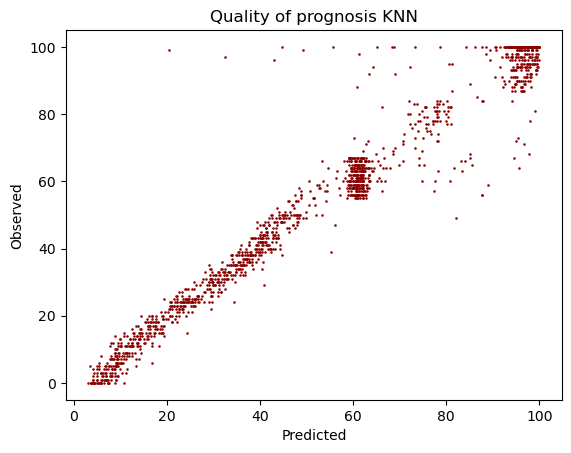

In [26]:
plt.scatter(y_pred,y_test, s=0.7, color = 'darkred')
plt.title('Quality of prognosis KNN')
plt.xlabel('Predicted')
plt.ylabel('Observed')
plt.show()

<div class="alert alert-block alert-success">
The coefficient of determination (R²) is 0.96, indicating that the model explains approximately 96% of the variability in the target variable. The RMSE corresponds to 12.24% of the mean value of the target variable, which also indicates relatively good predictive performance.<br>

The scatter plot comparing the actual and predicted values shows that the model performs relatively well, as most observations are concentrated around the diagonal line representing perfect predictions. However, some dispersion around this line is still visible, indicating that the predictions are not perfectly aligned with the actual values.
<div>

### **Random forest**

In [27]:
X = data[['asortyment','plec','wiek','dochod','dni','inne','odleglosc','zakupy','internet']]
X.head()

,asortyment,plec,wiek,dochod,dni,inne,odleglosc,zakupy,internet
0,54,0,54,2.1,2,3,1.6,1,0
1,86,1,72,2.3,6,2,6.5,1,0
2,56,1,56,2.1,2,3,0.4,1,0
3,54,1,60,2.1,2,3,6.5,1,0
4,63,1,41,2.1,2,3,7.3,1,0


In [28]:
y = data['obsluga']

In [29]:
# creation of train and test set - 20% of data is test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=123)

In [30]:
#training model with 300 trees
rf_reg = RandomForestRegressor(n_estimators = 300, random_state=123)
rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)

The regression model was then evaluated using the **coefficient of determination (R²)** and the **Root Mean Squared Error (RMSE)**.

In [31]:
mse = mean_squared_error(y_test,y_pred)
rmse = mse ** (1 / 2)
print('MSE:', mse)
print('RMSE:', rmse)

MSE: 20.601768109474936
RMSE: 4.538917063515805


In [32]:
y_mean = y_test.mean()
print(rmse/y_mean * 100)

8.421059152190116


In [33]:
r2 = r2_score(y_test,y_pred)
print('r2:',r2)

r2: 0.9793265936911631


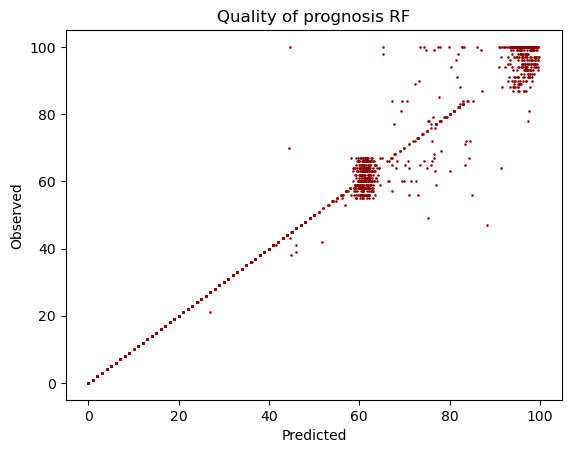

In [34]:
plt.scatter(y_pred,y_test, s=0.7, color = 'darkred')
plt.title('Quality of prognosis RF')
plt.xlabel('Predicted')
plt.ylabel('Observed')
plt.show()

<div class="alert alert-block alert-success">
The coefficient of determination (R²) is 0.98, indicating a very good fit between the predicted and actual values. The RMSE corresponds to 8.42% of the mean value of the target variable, which also indicates good to very good predictive performance.<br>

The scatter plot of predicted versus actual values shows that the model generally performs well in predicting the target variable. Nevertheless, there are some regions in which the observations deviate from the expected linear pattern. Overall, this model achieves better predictive performance than the KNN algorithm.
<div>

Next, the importance of individual features was evaluated.

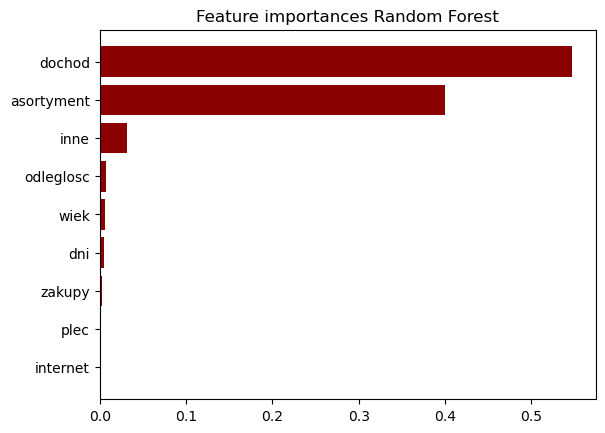

In [35]:
features = pd.DataFrame(rf_reg.feature_importances_, 
                        index=X.columns, columns=['Importances'])
features.sort_values(by=['Importances'], inplace=True)
plt.barh(features.index, features['Importances'], color='darkred')
plt.title('Feature importances Random Forest')
plt.show()

In the model presented above, **income** was the most important feature, accounting for almost 60% of the total feature importance. **Satisfaction with the product range** also played a significant role in the model. The remaining variables showed relatively low importance in predicting the target variable.

### **Extra trees**

In [36]:
#model training - 300 trees
ext_reg = ExtraTreesRegressor(n_estimators = 300, 
                                random_state=123)
ext_reg.fit(X_train, y_train)

ExtraTreesRegressor(n_estimators=300, random_state=123)

In [37]:
#prediction
y_pred = ext_reg.predict(X_test)

Next, the performance of the regressor was evaluated. In particular, it was compared with the **Random Forest** algorithm, as Extra Trees is closely related to Random Forest and introduces additional randomization into the tree-building process.

In [38]:
mse = mean_squared_error(y_test,y_pred)
rmse = mse ** (1 / 2)
print('MSE:', mse)
print('RMSE:', rmse)

MSE: 18.974672385839654
RMSE: 4.355992698093014


In [39]:
y_mean = y_test.mean()
print(rmse/y_mean * 100)

8.081679322145598


In [40]:
r2 = r2_score(y_test,y_pred)
print('r2:',r2)

r2: 0.9809593472887833


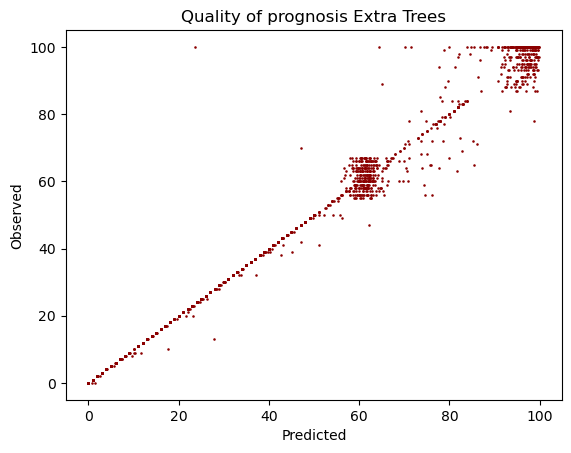

In [41]:
plt.scatter(y_pred,y_test, s=0.7, color = 'darkred')
plt.title('Quality of prognosis Extra Trees')
plt.xlabel('Predicted')
plt.ylabel('Observed')
plt.show()

<div class="alert alert-block alert-success">
The coefficient of determination (R²) is 0.98, indicating a very good fit between the predicted and actual values. The RMSE corresponds to 8.08% of the mean value of the target variable, which also indicates good to very good predictive performance.<br>

The scatter plot of predicted versus actual values shows that the model generally performs well in predicting the target variable. However, similarly to the Random Forest model, there are some regions where the observations deviate from the expected linear pattern. Overall, the Extra Trees model achieves better predictive performance than the previously evaluated algorithms.<div>

Text(0.5, 1.0, 'Feature Importances Extra Trees')

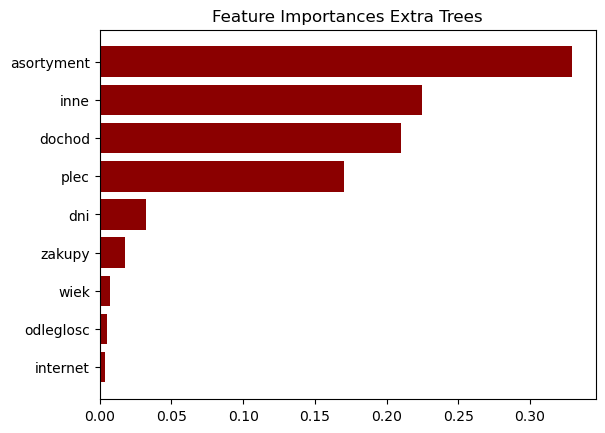

In [42]:
features = pd.DataFrame(ext_reg.feature_importances_, index=X.columns, columns=['Importances'])
features.sort_values(by=['Importances'], inplace=True)
plt.barh(features.index, features['Importances'], color='darkred')
plt.title('Feature Importances Extra Trees')

In the model presented above, **satisfaction with the product range** was the most important feature, accounting for more than 30% of the total feature importance. In contrast to the Random Forest model, the Extra Trees model assigned relatively high importance to a broader set of variables, including the **number of other supermarkets visited**, **customer income**, and **gender**.

## <font color='indianred'> **Problem klasyfikacyjny** </font>

The objective of the classification task is to predict whether a given customer intends to shop at Supermarket X in the future. The classification was performed using nine variables considered potentially relevant to the problem: <br>

Product range – customer satisfaction with the product range offered by Supermarket X <br>
Customer service – customer satisfaction with the service provided by Supermarket X, <br>
Days – number of days per week on which the customer goes shopping, <br>
Income – average customer income <br>
Other supermarkets – number of other supermarkets at which the customer shops, <br>
Online shopping – whether the customer shops online (0 – no, 1 – yes), <br>
Age – customer age in years, <br>
Gender – 0 – male, 1 – female, <br>
Distance – distance between the customer’s place of residence and the supermarket, measured in kilometres <br>

The credit card and loan variables were excluded from the analysis, as no substantive rationale was identified for retaining them as predictors of future purchase intention.

### **Logistic regression**

In [43]:
X = data[['asortyment','obsluga','dni','dochod','inne','internet','wiek','plec','odleglosc']]
X.head()

,asortyment,obsluga,dni,dochod,inne,internet,wiek,plec,odleglosc
0,54,64,2,2.1,3,0,54,0,1.6
1,86,88,6,2.3,2,0,72,1,6.5
2,56,60,2,2.1,3,0,56,1,0.4
3,54,61,2,2.1,3,0,60,1,6.5
4,63,60,2,2.1,3,0,41,1,7.3


In [44]:
y = data['zakupy']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: zakupy, dtype: int64

Before performing the classification, the class distribution was examined to determine whether the target classes were balanced.

<Axes: xlabel='zakupy'>

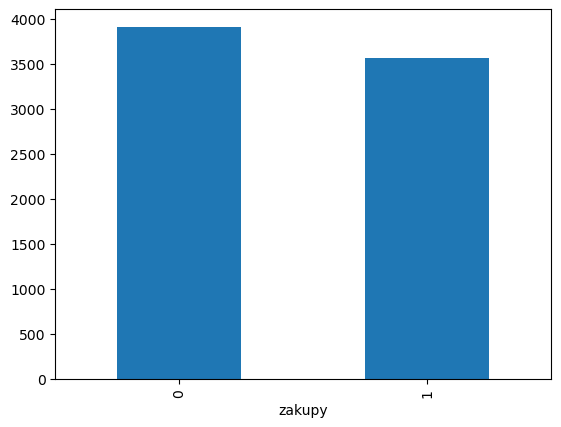

In [45]:

y.value_counts().plot.bar()

The classes contain a similar number of observations; therefore, the dataset can be considered relatively well balanced.

In [46]:
# Dataset splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [47]:
# Model training
log_clf = LogisticRegression(max_iter=200)
log_clf.fit(X_train, y_train)

C:\Users\augus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

In [48]:
# Wartości współczynników
print(log_clf.coef_)
print(log_clf.intercept_)

[[-0.00591268  0.01699402 -0.07036732  0.3217389  -0.70575137  0.09330384
   0.00957885  0.36017055 -0.01881965]]
[0.63846545]


In [49]:
# Predykcja dla zbioru testowego
y_pred = log_clf.predict(X_test)

Next, the performance of the classifier was evaluated using **accuracy**, the **confusion matrix**, and the performance metrics derived from it.

In [50]:
# Accuracy
log_clf.score(X_test, y_test)

0.8199464524765729

In [51]:
# Confusion matrics
print(confusion_matrix(y_test, y_pred))

[[657 106]
 [163 568]]


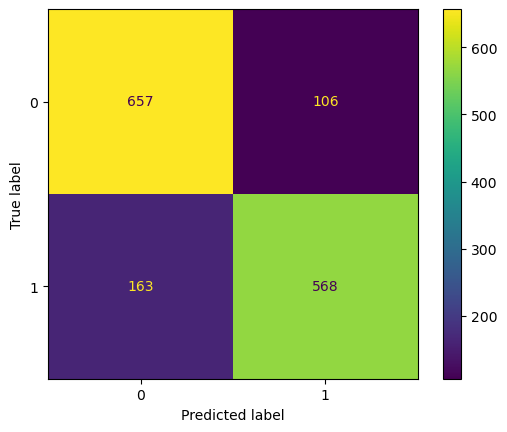

In [52]:
# Confusion matrics visualisation
ConfusionMatrixDisplay.from_estimator(log_clf, X_test, y_test)

In [53]:
# metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       763
           1       0.84      0.78      0.81       731

    accuracy                           0.82      1494
   macro avg       0.82      0.82      0.82      1494
weighted avg       0.82      0.82      0.82      1494



<div class="alert alert-block alert-success">
The accuracy of the logistic regression classifier is 0.82, meaning that 82% of customers were classified correctly. This indicates good overall classification performance. The model performs better at identifying customers who do not intend to shop at Supermarket X in the future (657 correctly classified and 106 misclassified) than customers who do intend to shop there (568 correctly classified and 163 misclassified).

For class 0, precision is 0.80, meaning that among customers classified as not intending to shop at Supermarket X, 80% actually belong to this class. Recall for class 0 is 0.86, indicating that 86% of customers who actually do not intend to shop at the supermarket were correctly identified by the model.

For class 1, precision is 0.84, meaning that 84% of customers classified as intending to shop at Supermarket X actually belong to this class. Recall for class 1 is 0.78, indicating that 78% of customers who actually intend to shop at the supermarket were correctly identified.

The F1-score is 0.02 higher for class 0 than for class 1, indicating slightly better classification performance for customers who do not intend to shop at Supermarket X.
<div>

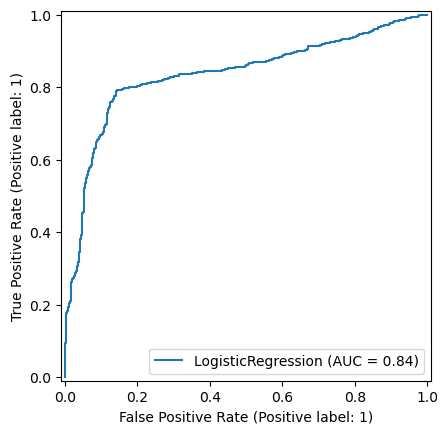

In [54]:
# ROC
ROC = RocCurveDisplay.from_estimator(log_clf, X_test, y_test)

The **Area Under the ROC Curve (AUC)** is **0.84**, which further indicates good discriminatory performance of the classifier.

### **Decision tree**

In [55]:
# Dataset splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

Using the **Grid Search** method, two hyperparameters were tuned: **max_depth** and **criterion**.<br>

The **max_depth** hyperparameter specifies the maximum depth of the decision tree. By default, the tree is allowed to grow without a predefined maximum depth. In this analysis, values of **max_depth** up to 15 were considered.<br

The **criterion** hyperparameter determines the function used to evaluate the quality of a split in the decision tree. Two splitting criteria were considered: **Gini impurity** and **entropy**.

In [56]:
# Model training
dt_clf = DecisionTreeClassifier(criterion='entropy', 
                                max_depth=5, 
                                random_state=123)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=123)

In [57]:
# Hyperparameter tuning
my_search = GridSearchCV(dt_clf,
                          param_grid={'max_depth':range(1,15),
                                     'criterion':['gini','entropy']},cv=5, scoring='accuracy')
my_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(criterion='entropy', max_depth=5,
                                              random_state=123),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 15)},
             scoring='accuracy')

In [58]:
# Wyniki
print(my_search.best_params_)
print(my_search.best_score_)

{'criterion': 'gini', 'max_depth': 5}
0.8423430962343096


The splitting criterion selected for the decision tree was **entropy**, while the maximum tree depth (**max_depth**) was set to **5**.

In [59]:
y_pred = dt_clf.predict(X_test)

In [60]:
# Accuracy
dt_clf.score(X_test, y_test)

0.8299866131191432

In [61]:
# Confusion matrics
print(confusion_matrix(y_test, y_pred))

[[662 101]
 [153 578]]


<Figure size 500x500 with 0 Axes>

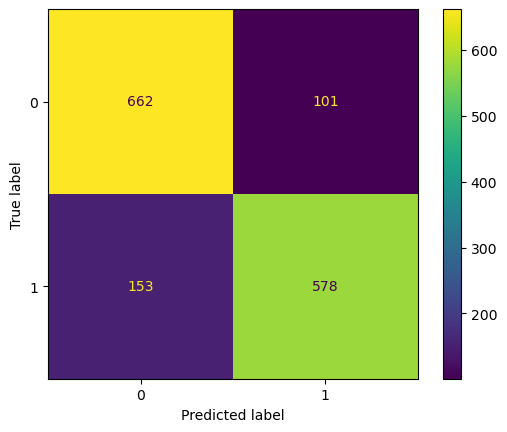

In [62]:

plt.figure(figsize=(5,5))
ConfusionMatrixDisplay.from_estimator(dt_clf, X_test, y_test)

In [63]:
# metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       763
           1       0.85      0.79      0.82       731

    accuracy                           0.83      1494
   macro avg       0.83      0.83      0.83      1494
weighted avg       0.83      0.83      0.83      1494



<div class="alert alert-block alert-success">
The classification tree achieved an **accuracy of 0.83**. Precision was **0.81 for class 0** and **0.85 for class 1**, indicating good predictive performance for both classes. <br>

Recall for class 0 was **0.87**, meaning that 87% of customers who actually did not intend to shop at Supermarket X were correctly classified. For class 1, recall was lower at **0.79**, meaning that 79% of customers who actually intended to shop at the supermarket were correctly identified.<br>

The **F1-scores** for classes 0 and 1 were **0.84 and 0.82**, respectively. Overall, the classification tree demonstrated good predictive performance.
<div>

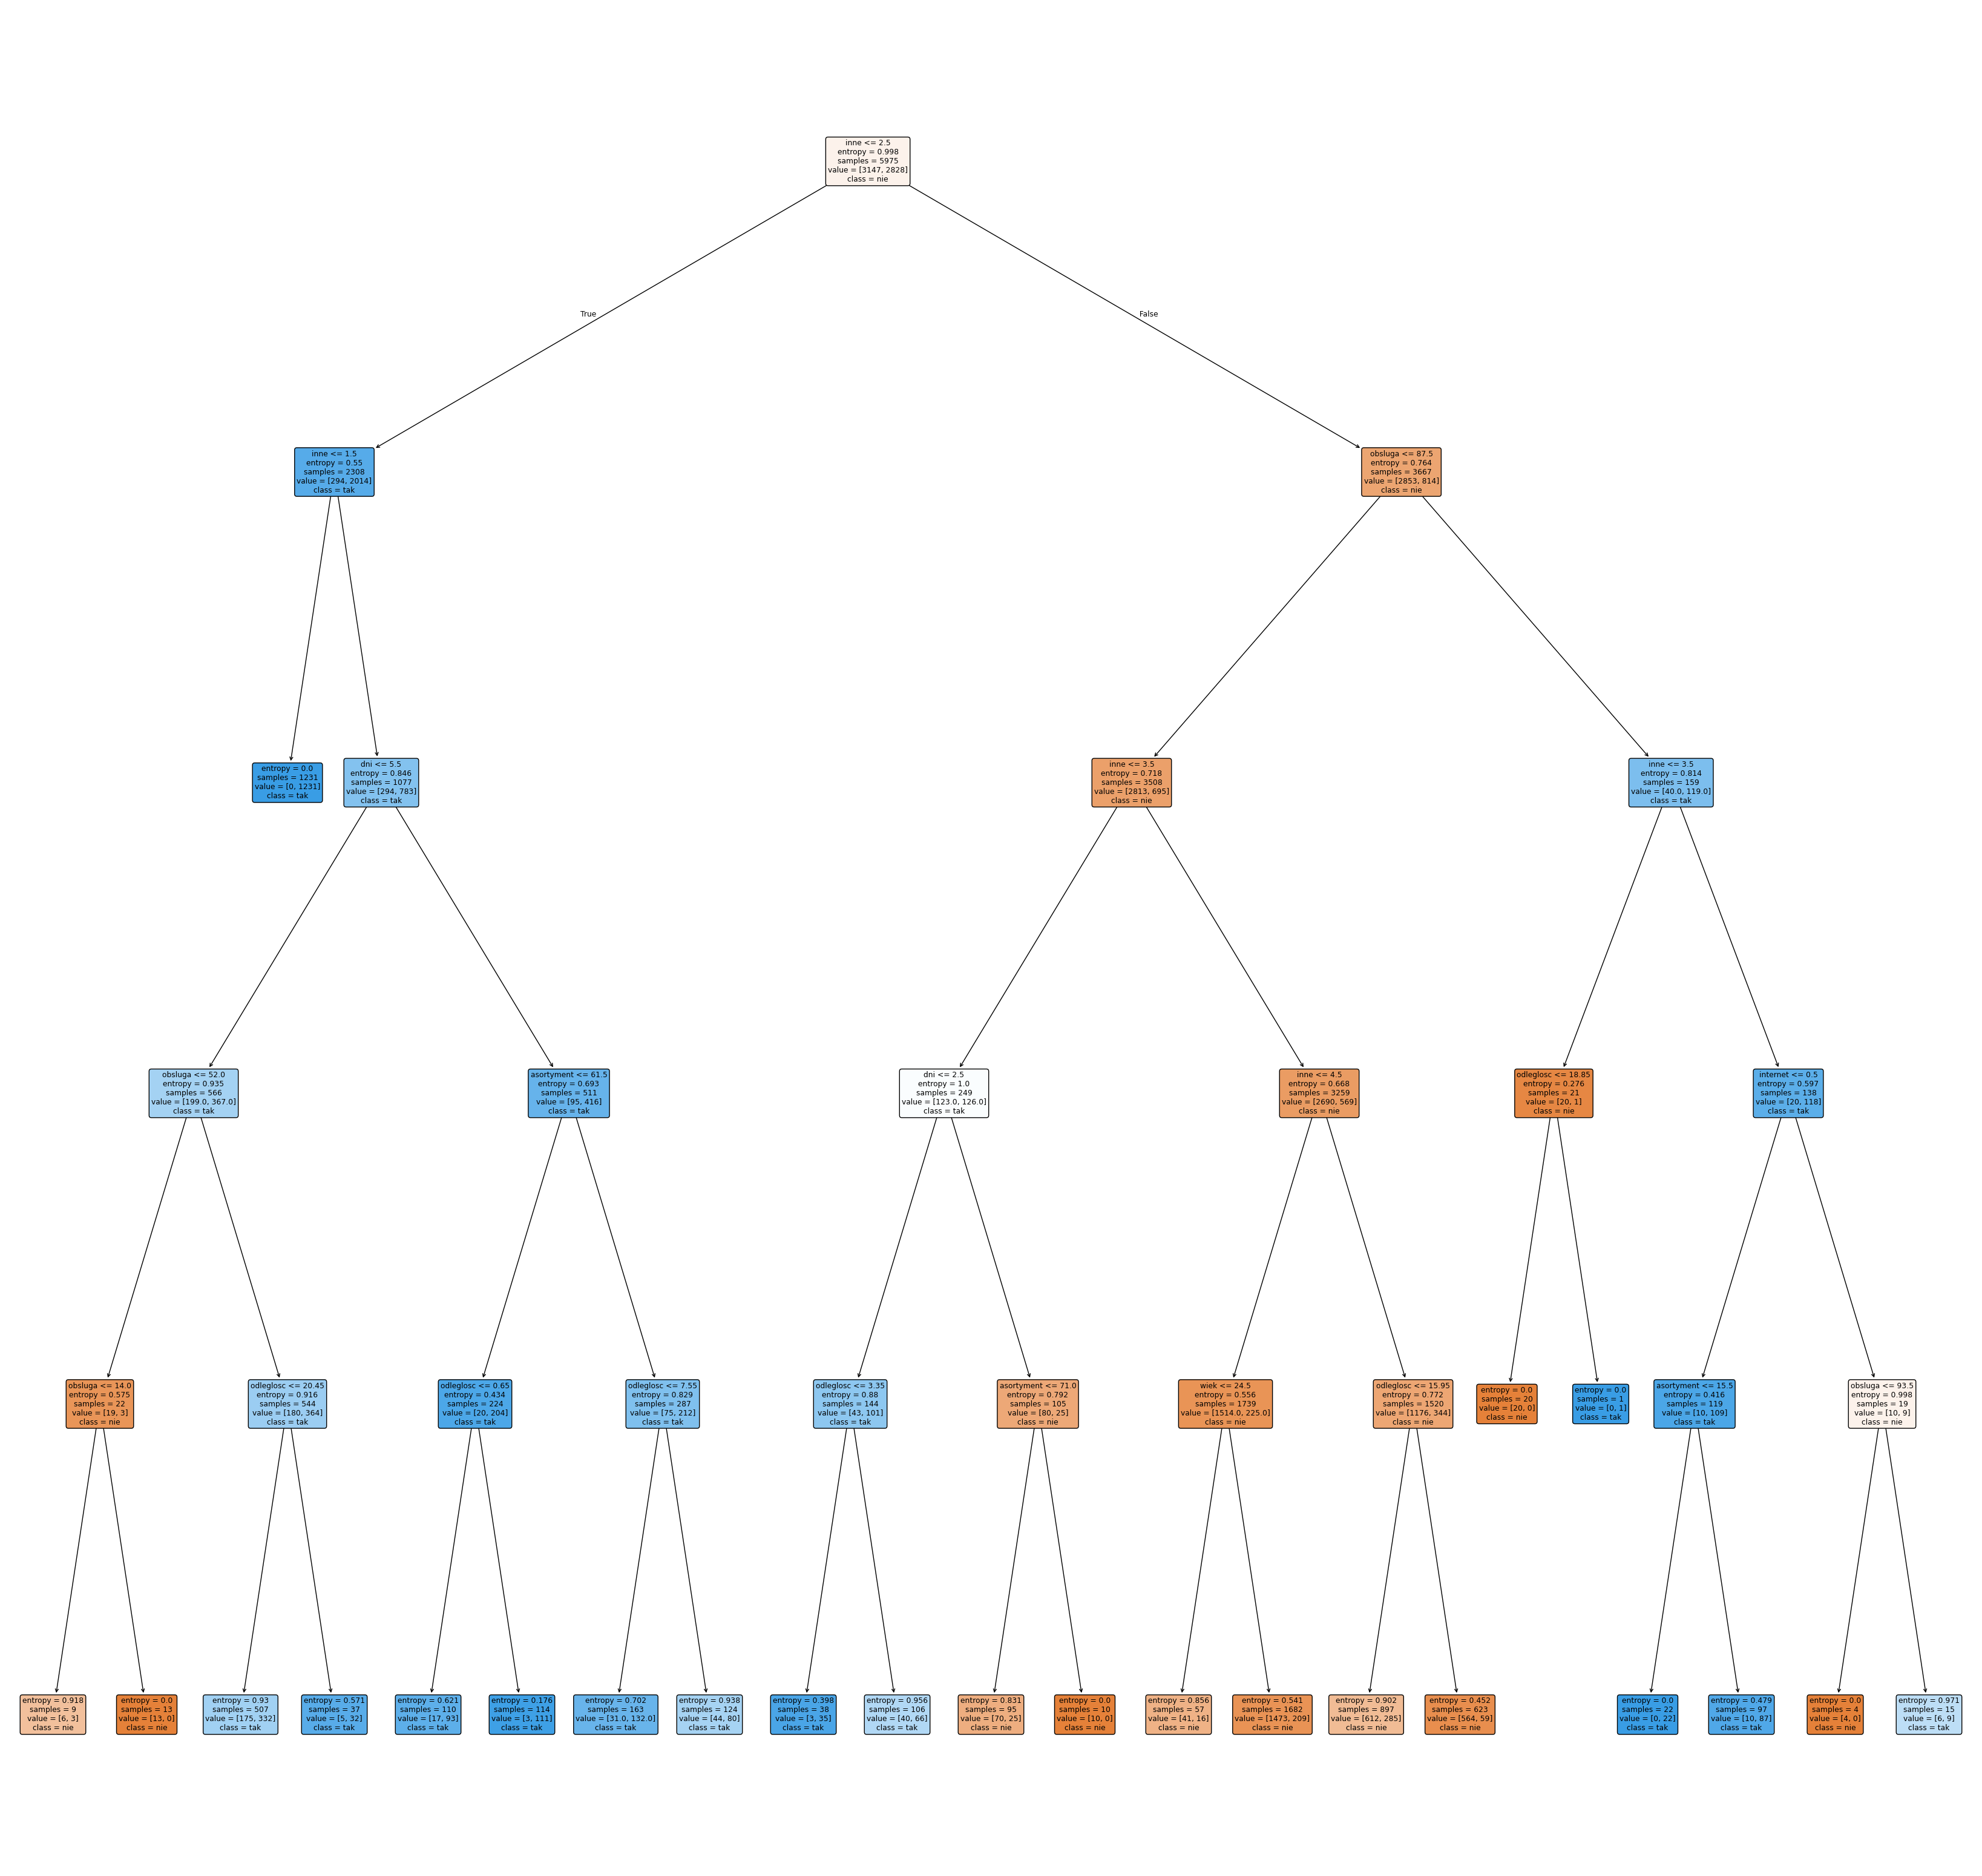

In [64]:
# Tree visualisation
plt.figure(figsize=(42,40))
figure = plot_tree( dt_clf,
                   class_names=['nie','tak'], 
                   feature_names= ['asortyment','obsluga','dni','dochod','inne','internet','wiek','plec','odleglosc'], 
                   filled=True, 
                   rounded=True)

In [65]:
# Znaczenie cech 
dt_clf.feature_importances_

array([0.00924058, 0.06328143, 0.02343804, 0.        , 0.85446782,
       0.00489804, 0.00242264, 0.        , 0.04225145])

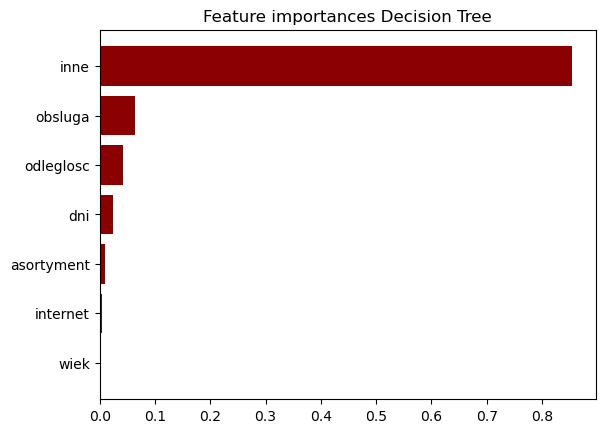

In [66]:
# Prezentacja graficzna znaczenia cech
features = pd.DataFrame(dt_clf.feature_importances_, index=X.columns, columns=['Importances'])
features = features[features['Importances'] > 0]
features.sort_values(by=['Importances'], inplace=True)
plt.barh(features.index, features['Importances'], color='darkred')
plt.title('Feature importances Decision Tree')
plt.show()

The **number of other supermarkets at which the customer shops** was by far the most important feature in predicting whether a customer intends to shop at Supermarket X in the future, accounting for more than **80% of the total feature importance** in the decision tree model. The remaining variables showed relatively low importance.

### **Random forest**

In [67]:
# Dataset splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [68]:
# Model training
rf_clf = RandomForestClassifier(n_estimators=300, random_state=123, n_jobs=-1)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=123)

In [69]:
# Prediction
y_pred = rf_clf.predict(X_test)

In [70]:
# Accuracy
rf_clf.score(X_test, y_test)

0.8232931726907631

In [71]:
# Confusion matrics
print(confusion_matrix(y_test, y_pred))

[[655 108]
 [156 575]]


<Figure size 500x500 with 0 Axes>

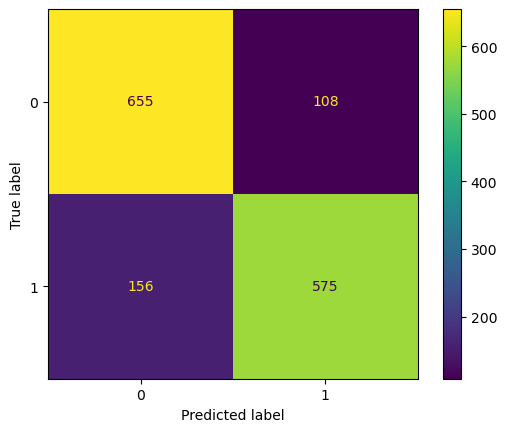

In [72]:
# Confusiom matrics visualisation
plt.figure(figsize=(5,5))
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test, y_test)

Majority of clients are classified properly

In [73]:
# Metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       763
           1       0.84      0.79      0.81       731

    accuracy                           0.82      1494
   macro avg       0.82      0.82      0.82      1494
weighted avg       0.82      0.82      0.82      1494



<div class="alert alert-block alert-success">
The Random Forest model achieved an **accuracy of 0.82**, meaning that 82% of customers were classified correctly. Precision was **0.81 for class 0** and **0.84 for class 1**, indicating good predictive performance for both classes.
Recall for class 0 was **0.86**, meaning that 86% of customers who actually did not intend to shop at Supermarket X were correctly classified. For class 1, recall was lower at **0.79**, meaning that 79% of customers who actually intended to shop at the supermarket were correctly identified.
The **F1-scores** for classes 0 and 1 were **0.83 and 0.81**, respectively. Overall, the predictive performance of the Random Forest model was similar to that of the decision tree model.
<div>

In [74]:
# Features importances
rf_clf.feature_importances_

array([0.08977906, 0.18511886, 0.04003618, 0.11598322, 0.25283562,
       0.02088586, 0.1028636 , 0.06041628, 0.13208132])

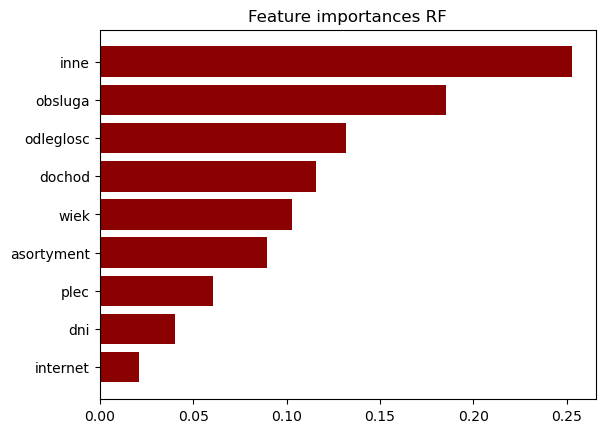

In [75]:

features = pd.DataFrame(rf_clf.feature_importances_, index=X.columns, columns=['Importances'])
features.sort_values(by=['Importances'], inplace=True)
plt.barh(features.index, features['Importances'], color='darkred')
plt.title('Feature importances RF')
plt.show()

Similarly to the decision tree model, the **number of other supermarkets at which the customer shops** was the most important feature in the Random Forest model, with a feature importance of approximately **0.25**. **Customer service satisfaction, distance, income, and age** also showed relatively high importance. In contrast, **product range satisfaction, gender, number of shopping days, and online shopping** had relatively low importance, with values below **0.10**.

## <font color='indianred'> **Summary** </font>

### **Regression**

Three machine learning methods were used to predict customer satisfaction with the service provided by Supermarket X: **K-Nearest Neighbors (KNN), Random Forest, and Extra Trees**.<br>
For the KNN model, the coefficient of determination (R²) was **0.96**, while the RMSE corresponded to approximately **12% of the mean value of the target variable**. The Random Forest model achieved better predictive performance, with an R² of **0.98** and an RMSE corresponding to **8.42% of the mean target value**. The Extra Trees model performed slightly better than Random Forest, achieving a similar R² of **0.98** but a lower relative RMSE of **8.08%**. Therefore, among the models evaluated in this study, **Extra Trees was selected as the preferred model for predicting customer service satisfaction**.<br>
The results suggest that machine learning techniques can be successfully applied to predict customer satisfaction with service at Supermarket X. However, future analyses should consider incorporating additional explanatory variables. Further investigation should also focus on the relationship between **customer service satisfaction and product range satisfaction**, particularly among customers who intend to shop at the supermarket again. The regions in which all three models show relatively poorer predictive performance appear to approximately coincide with the regions where the relationship between these two variables becomes weaker. Exploring this pattern in greater detail may help improve the predictive performance of future models.

### **Classification**

The application of machine learning techniques also produced good results for the classification task, which aimed to predict whether a customer intends to shop at **Supermarket X** in the future. Three classification methods were evaluated: **Logistic Regression, Decision Tree, and Random Forest**.<br>
The classification accuracy was **0.82** for both Logistic Regression and Random Forest and **0.83** for the Decision Tree. The remaining performance metrics, including **precision, recall, and F1-score**, were also similar across the three models, indicating that none of the evaluated approaches substantially outperformed the others in terms of predictive performance.<br>
All three models can therefore be considered suitable for predicting customers’ future purchase intentions, as they demonstrated good and comparable classification performance. However, the **Decision Tree offers an additional advantage in terms of interpretability**, as its decision-making process can be more easily examined and explained. Considering both predictive performance and interpretability, the Decision Tree was selected as the preferred model for this classification task.